In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
customers = pd.read_csv("../dataset/customers (1).csv")
credit = pd.read_csv("../dataset/credit_history.csv")
loans = pd.read_csv("../dataset/loan_applications.csv")
transactions = pd.read_csv("../dataset/transactions.csv")

# Merge datasets
merged = pd.merge(customers, credit, on="customer_id", how="left")
merged = pd.merge(merged, loans, on="customer_id", how="left")

print("Dataset Loaded Successfully!")
print(merged.shape)

Dataset Loaded Successfully!
(8596, 49)


approval_status
Rejected        3924
Approved        3403
Under Review     173
Name: count, dtype: int64


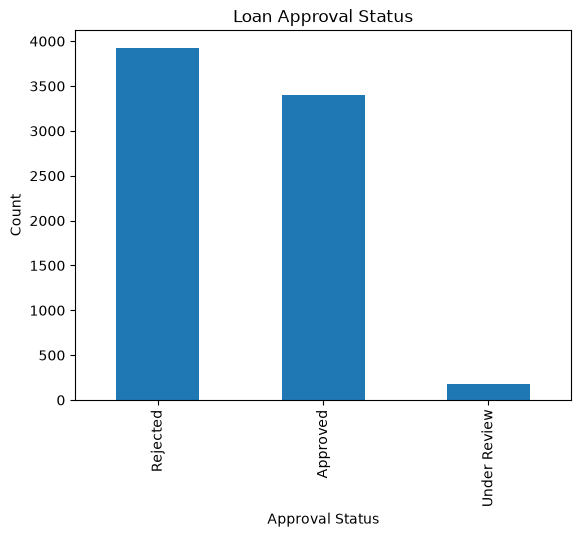

In [3]:
import matplotlib.pyplot as plt

# Count loan approvals
approval_counts = merged["approval_status"].value_counts()

print(approval_counts)

approval_counts.plot(kind="bar")
plt.title("Loan Approval Status")
plt.xlabel("Approval Status")
plt.ylabel("Count")
plt.show()

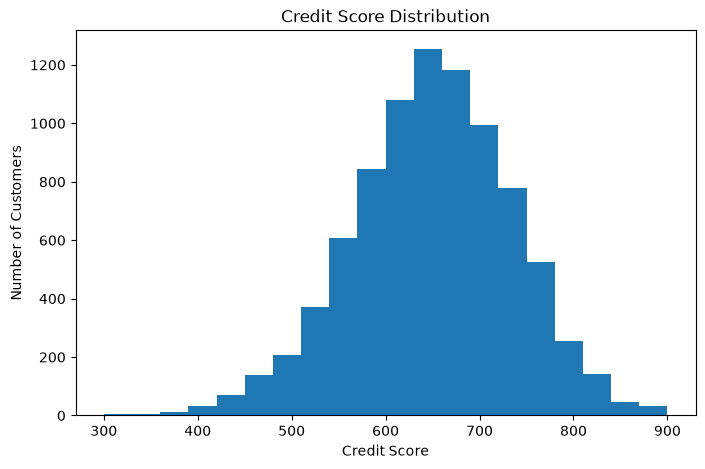

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(merged["credit_score"], bins=20)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

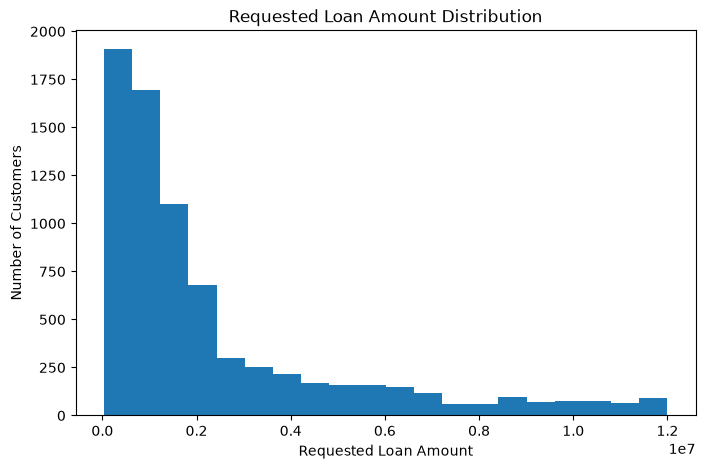

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    merged["requested_amount"].dropna(),
    bins=20
)

plt.title("Requested Loan Amount Distribution")
plt.xlabel("Requested Loan Amount")
plt.ylabel("Number of Customers")

plt.show()

employment_type
Salaried          4663
Self-Employed     1772
Business Owner    1066
Retired            617
Unemployed         478
Name: count, dtype: int64


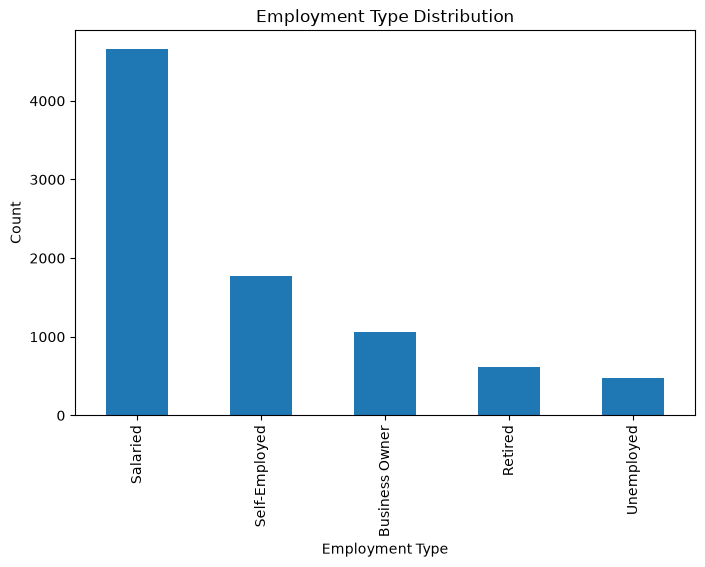

In [6]:
employment = merged["employment_type"].value_counts()

print(employment)

employment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Count")

plt.show()

Risk Category
Low Risk       8135
Medium Risk     454
High Risk         7
Name: count, dtype: int64


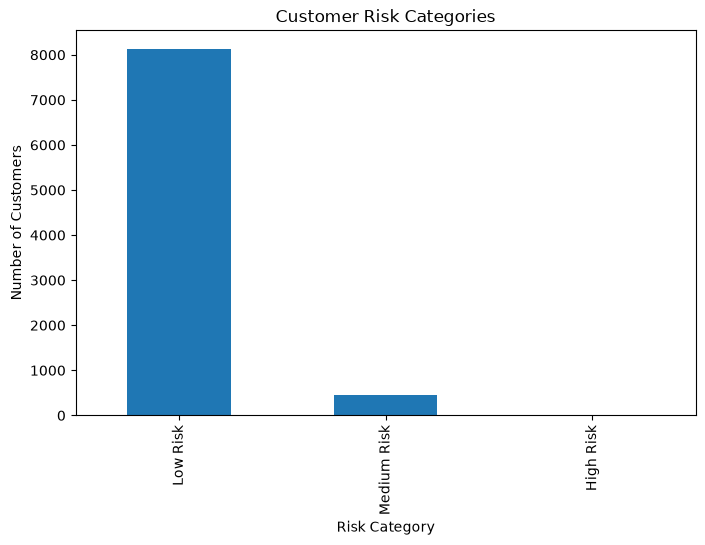

In [7]:
risk_score = (
    merged["num_defaults_prior"] * 10 +
    merged["num_late_payments_90d"] * 5 +
    merged["bankruptcies"] * 20 +
    merged["credit_utilization_ratio"] * 10
)

merged["Risk Score"] = risk_score

merged["Risk Category"] = pd.cut(
    merged["Risk Score"],
    bins=[-1, 20, 50, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk = merged["Risk Category"].value_counts()

print(risk)

risk.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()